# Faster R-CNN Experiments: GOST Stamp Detection

**Цель:** Обучить Faster R-CNN для детекции штампов на строительных чертежах.

**Данные:** 500 synthetic train_v3 + 10 real val_honest + 35 real test

**Метрики:** IoU, Precision, Recall, F1 на 49 реальных изображениях

**Подход:** Single training run, ResNet50 FPN backbone, 30 epochs, GPU T4 (Colab)

**Resize:** Компромисс — synthetic (200 DPI) ресайзится по PPI (100), real — fallback на 800px.


## 1. Colab Setup

⚠️ **Запустить только один раз!** Клонирует репозиторий (sparse checkout) и устанавливает зависимости.


In [1]:
import os
import sys
import random
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    %cd /content
    !rm -rf aie-group-2-sapar
    !git init aie-group-2-sapar
    %cd aie-group-2-sapar
    !git sparse-checkout set project
    !git remote add origin https://github.com/Sapar-hub/aie-group-2-sapar.git
    !git pull origin main
    %cd project
    !pip install -q ultralytics opencv-python-headless pyyaml
    !nvidia-smi
    # Load pre-generated training data from Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    import shutil
    DRIVE_DATA = Path('/content/drive/MyDrive/aie-group-2-data')
    if (DRIVE_DATA / 'images' / 'train_v3').exists():
        for subdir in ['images', 'labels']:
            shutil.copytree(str(DRIVE_DATA / subdir), str(Path('data') / subdir), dirs_exist_ok=True)
        print("Training data loaded from Google Drive")
    else:
        print("=" * 60)
        print("No pre-generated data found on Drive!")
        print("Run notebooks/exp02_synthetic_data.ipynb first to generate it.")
        print("=" * 60)
    PROJECT_DIR = Path.cwd()
    sys.path.insert(0, str(PROJECT_DIR / "src"))
else:
    os.environ["CUDA_VISIBLE_DEVICES"] = ""
    PROJECT_DIR = Path.cwd().parent
    sys.path.insert(0, str(PROJECT_DIR / "src"))


/content
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/aie-group-2-sapar/.git/
/content/aie-group-2-sapar
remote: Enumerating objects: 1140, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 1140 (delta 15), reused 12 (delta 10), pack-reused 1114 (from 1)
Receiving objects: 100% (1140/1140), 552.40 MiB | 20.72 MiB/s, done.
Resolving deltas: 100% (365/365), done.
From https://github.com/Sapar-hub/aie-group-2-sapar
 * branch            main       ->

## 2. Imports & Data Setup

In [2]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2
from torch.utils.data import Dataset, DataLoader, Subset

from evaluation.metrics import DetectionResult, bbox_iou, yolo_to_pixel, compute_metrics, print_metrics
from data.loader import load_image_and_labels

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DATA_DIR = PROJECT_DIR / "data"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)
(ARTIFACTS_DIR / "models").mkdir(exist_ok=True)
(ARTIFACTS_DIR / "metrics").mkdir(exist_ok=True)
(ARTIFACTS_DIR / "figures").mkdir(exist_ok=True)

IMAGE_TEST_DIR = DATA_DIR / "images" / "test"
LABEL_TEST_DIR = DATA_DIR / "labels" / "test"
IMAGE_TRAIN_DIR = DATA_DIR / "images" / "train_v3"
LABEL_TRAIN_DIR = DATA_DIR / "labels" / "train_v3"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Train images: {len(list(IMAGE_TRAIN_DIR.glob('*.png')) + list(IMAGE_TRAIN_DIR.glob('*.jpg')))}")
print(f"Test images: {len(list(IMAGE_TEST_DIR.glob('*.png')) + list(IMAGE_TEST_DIR.glob('*.jpg')))}")

# Donors (stamp sources for copy-paste) excluded from eval metrics
DONORS = {"test_09.jpg", "test_14.png", "test_34.jpg", "test_49.jpg"}
VAL_HONEST_DIR = DATA_DIR / "images" / "val_honest"
VAL_HONEST = {p.name for p in VAL_HONEST_DIR.glob("*") if p.suffix in (".jpg", ".png")}
TEST_EXCLUDE = DONORS | VAL_HONEST
print(f"Donors excluded from eval: {sorted(DONORS)}")
print(f"Val_honest excluded from eval: {sorted(VAL_HONEST)}")
print(f"Test images will be: 49 - {len(TEST_EXCLUDE)} = {49 - len(TEST_EXCLUDE)}")

Device: cuda
Train images: 408
Test images: 49
Donors excluded from eval: ['test_09.jpg', 'test_14.png', 'test_34.jpg', 'test_49.jpg']


## 3. Dataset & DataLoader

**Компромисс PPI:**
- Synthetic (train): DPI=200 известен → ресайз по целевому PPI (100).
  Штамп 185×55mm всегда ~728×216px — единый физический масштаб.
- Real (test): PPI неизвестен → fallback на MAX_SIZE=800 по длинной стороне.
- Bbox корректируются пропорционально scale.
- Цель: synthetic учится на физических размерах, real не ломается.

In [3]:
# ─── Compromise: PPI-based resize for synthetic (known DPI),
#     pixel-based fallback for real (unknown PPI).
# Synthetic: generated at 200 DPI → resample to TARGET_PPI so
#   stamp ~185mm всегда имеет одинаковый физический масштаб.
# Real: PPI неизвестен, fallback на MAX_SIZE.
TARGET_PPI = 100
SYNTH_DPI = 200
MAX_SIZE = 800

def resize_ppi(image, boxes, src_ppi, target_ppi=TARGET_PPI):
    """Resize based on physical PPI ratio. Preserves real-world scale."""
    scale = target_ppi / src_ppi
    if scale >= 1.0:
        return image, boxes, 1.0
    new_w = int(image.shape[1] * scale)
    new_h = int(image.shape[0] * scale)
    image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    if len(boxes) > 0:
        boxes = boxes * scale
    return image, boxes, scale

def resize_maxsize(image, boxes, max_size=MAX_SIZE):
    """Fallback: resize so longest side <= max_size."""
    h, w = image.shape[:2]
    scale = max_size / max(h, w)
    if scale >= 1.0:
        return image, boxes, 1.0
    new_w, new_h = int(w * scale), int(h * scale)
    image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    if len(boxes) > 0:
        boxes = boxes * scale
    return image, boxes, scale

class GOSTDataset(Dataset):
    def __init__(self, image_dir, label_dir, synth_dpi=None):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.synth_dpi = synth_dpi
        self.image_paths = sorted(list(self.image_dir.glob("*.png")) + list(self.image_dir.glob("*.jpg")))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        label_file = self.label_dir / f"{img_path.stem}.txt"
        if label_file.exists():
            with open(label_file) as f:
                labels = [list(map(float, line.strip().split())) for line in f if line.strip()]
        else:
            label_files = list(self.label_dir.glob(f"*-{img_path.stem}.txt"))
            if label_files:
                with open(label_files[0]) as f:
                    labels = [list(map(float, line.strip().split())) for line in f if line.strip()]
            else:
                labels = []
        boxes = []
        for label in labels:
            _, cx, cy, bw, bh = label
            x1 = (cx - bw / 2) * w
            y1 = (cy - bh / 2) * h
            x2 = (cx + bw / 2) * w
            y2 = (cy + bh / 2) * h
            boxes.append([x1, y1, x2, y2])
        boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32)

        if self.synth_dpi is not None:
            img, boxes, _ = resize_ppi(img, boxes, self.synth_dpi)
        else:
            img, boxes, _ = resize_maxsize(img, boxes)
        img_tensor = F.to_tensor(img)

        labels_tensor = torch.ones(len(boxes), dtype=torch.int64) if len(boxes) > 0 else torch.zeros(0, dtype=torch.int64)
        target = {"boxes": boxes, "labels": labels_tensor}
        return img_tensor, target

train_dataset = GOSTDataset(IMAGE_TRAIN_DIR, LABEL_TRAIN_DIR, synth_dpi=SYNTH_DPI)
test_dataset = GOSTDataset(IMAGE_TEST_DIR, LABEL_TEST_DIR)
print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

Train: 408, Test: 49


## 4. Data Split (v3 baseline)

Synthetic (500) → train (v3); Real (49) → test.
4 donors + 10 val_honest excluded from eval metrics.
Eval on 35 non-donor, non-val images gives unbiased accuracy estimate.

In [4]:
# ─── Synthetic 80/20 split (400 train + 100 val)
n_synth = len(train_dataset)
synth_indices = list(range(n_synth))
random.Random(RANDOM_STATE).shuffle(synth_indices)
n_val_synth = int(0.2 * n_synth)
val_synth_idx = synth_indices[:n_val_synth]
train_synth_idx = synth_indices[n_val_synth:]
print(f"Synthetic: {len(train_synth_idx)} train + {len(val_synth_idx)} val")

# ─── Real 80/20 split (39 val + 10 holdout test)
all_real_images = sorted(IMAGE_TEST_DIR.glob("*.png")) + sorted(IMAGE_TEST_DIR.glob("*.jpg"))
random.Random(RANDOM_STATE).shuffle(all_real_images)
n_val_real = int(0.8 * len(all_real_images))
val_images = all_real_images[:n_val_real]
test_images = all_real_images[n_val_real:]
print(f"Real: {len(val_images)} val + {len(test_images)} holdout test")
for p in test_images:
    print(f"  Holdout: {p.name}")

Synthetic: 327 train + 81 val
Real: 39 val + 10 holdout test
  Holdout: test_06.png
  Holdout: test_22.jpg
  Holdout: test_07.png
  Holdout: test_10.png
  Holdout: test_16.png
  Holdout: test_17.png
  Holdout: test_21.png
  Holdout: test_02.png
  Holdout: test_08.png
  Holdout: test_33.jpg


## 5. Training

Оптимизатор: Adam с дифференциальным LR (backbone `1e-4`, head `1e-3`).
Synthetic 500 all train (random 80/20 split for early stopping val). NaN/Inf check.

In [5]:
import time
start = time.time()

NUM_CLASSES = 2
NUM_EPOCHS = 30
BATCH_SIZE = 4
ACCUM_STEPS = 2  # effective batch size = BATCH_SIZE * ACCUM_STEPS = 8
LR_HEAD = 1e-3
LR_BACKBONE = 1e-4

model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, NUM_CLASSES)
model.to(DEVICE)

# Differential LR
backbone_params = []
head_params = []
for name, p in model.named_parameters():
    if 'box_predictor' in name:
        head_params.append(p)
    else:
        backbone_params.append(p)

optimizer = torch.optim.Adam([
    {'params': backbone_params, 'lr': LR_BACKBONE},
    {'params': head_params, 'lr': LR_HEAD},
], weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

train_subset = Subset(train_dataset, train_synth_idx)
val_subset = Subset(train_dataset, val_synth_idx)
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, collate_fn=lambda x: tuple(zip(*x)), num_workers=0, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, collate_fn=lambda x: tuple(zip(*x)), num_workers=0, pin_memory=True)

best_val_loss = float('inf')
patience = 5
wait = 0
best_epoch = 0
train_loss_history = []
val_loss_history = []

for epoch in range(NUM_EPOCHS):
    # Train
    model.train()
    epoch_loss = 0
    optimizer.zero_grad()
    for batch_idx, (images, targets) in enumerate(train_loader):
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        if not torch.isfinite(losses):
            print(f"NaN/Inf at epoch {epoch+1}, batch {batch_idx}, skipping")
            continue

        losses = losses / ACCUM_STEPS
        losses.backward()

        if (batch_idx + 1) % ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

        epoch_loss += losses.item() * ACCUM_STEPS
    lr_scheduler.step()
    avg_train_loss = epoch_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # Validate (train mode + no_grad for proper loss computation)
    model.train()
    with torch.no_grad():
        val_loss = 0
        for images, targets in val_loader:
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            output = model(images, targets)

            if isinstance(output, dict):
                val_loss += sum(v.item() for v in output.values())
            elif isinstance(output, list):
                for d in output:
                    if isinstance(d, dict):
                        val_loss += sum(v.item() for v in d.values())
    avg_val_loss = val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch
        wait = 0
        torch.save(model.state_dict(), str(ARTIFACTS_DIR / "models" / "rcnn_best.pth"))
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1}, best epoch {best_epoch+1}, best val loss {best_val_loss:.4f}")
            break

elapsed = time.time() - start
print(f"\nTraining time: {elapsed/60:.1f} minutes")

print(f"Weights saved to {ARTIFACTS_DIR / 'models' / 'rcnn_best.pth'}")
loss_history = train_loss_history
val_loss_history_print = val_loss_history

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 140MB/s]


Epoch 1/30, Train Loss: 0.0940, Val Loss: 0.0305
Epoch 5/30, Train Loss: 0.0095, Val Loss: 0.0088
Epoch 10/30, Train Loss: 0.0062, Val Loss: 0.0068
Epoch 15/30, Train Loss: 0.0018, Val Loss: 0.0027
Epoch 20/30, Train Loss: 0.0013, Val Loss: 0.0024
Epoch 25/30, Train Loss: 0.0011, Val Loss: 0.0021
Epoch 30/30, Train Loss: 0.0011, Val Loss: 0.0020

Training time: 105.0 minutes
Weights saved to /content/aie-group-2-sapar/project/artifacts/models/rcnn_best.pth


## 6. Loss Plot

Train + Val loss кривые. Early stopping отсекает лишние эпохи.

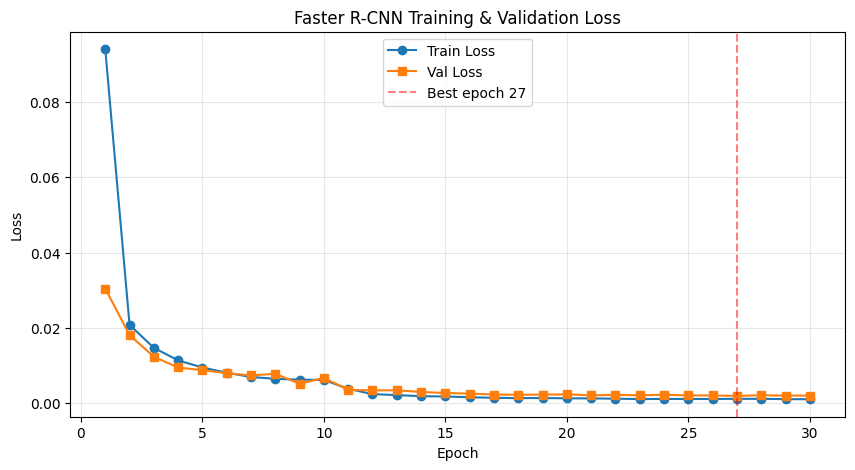

In [6]:
plt.figure(figsize=(10, 5))
best_epoch_display = best_epoch + 1
plt.plot(range(1, len(train_loss_history)+1), train_loss_history, marker="o", label="Train Loss")
plt.plot(range(1, len(val_loss_history)+1), val_loss_history, marker="s", label="Val Loss")
plt.axvline(x=best_epoch_display, color="r", linestyle="--", alpha=0.5, label=f"Best epoch {best_epoch_display}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Faster R-CNN Training & Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(ARTIFACTS_DIR / "figures" / "rcnn_loss.png", dpi=150)
plt.show()

## 7. Evaluation on 35 Non-Donor, Non-Val Images

All 49 real images = test set; 4 donors + 10 val_honest excluded from metrics.
Threshold sweep `[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.5]` + greedy matching (max IoU per GT).

In [7]:
THRESHOLDS = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.5]
best_f1 = 0.0
best_conf = 0.0
best_metrics = None
best_results = None

model.eval()

for conf_thresh in THRESHOLDS:
    results_list = []
    for img_path in all_real_images:
        img, labels = load_image_and_labels(img_path, LABEL_TEST_DIR)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        gt_bbox = yolo_to_pixel(tuple(labels[0]), w, h) if len(labels) > 0 else None

        gt_boxes = np.array([[gt_bbox[0], gt_bbox[1], gt_bbox[0]+gt_bbox[2], gt_bbox[1]+gt_bbox[3]]], dtype=np.float32) if gt_bbox else np.zeros((0, 4), dtype=np.float32)
        img_rgb, boxes_resized, _ = resize_maxsize(img_rgb, gt_boxes)
        if len(boxes_resized) > 0:
            x1, y1, x2, y2 = map(int, boxes_resized[0])
            gt_bbox = [x1, y1, x2 - x1, y2 - y1]

        img_tensor = F.to_tensor(img_rgb).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            preds = model(img_tensor)[0]

        boxes = preds["boxes"].cpu().numpy()
        scores = preds["scores"].cpu().numpy()

        # Highest-confidence prediction (no GT leakage)
        pred_bbox = None
        best_iou = 0.0
        mask = scores >= conf_thresh
        if mask.sum() > 0:
            best_idx = np.argmax(scores[mask])
            box = boxes[mask][best_idx]
            pred_bbox = (int(box[0]), int(box[1]), int(box[2]-box[0]), int(box[3]-box[1]))
            if gt_bbox:
                best_iou = bbox_iou(pred_bbox, gt_bbox)

        results_list.append(DetectionResult(
            image_name=img_path.name,
            gt_bbox=tuple(gt_bbox) if gt_bbox else None,
            pred_bbox=pred_bbox,
            iou=best_iou,
            found=pred_bbox is not None
        ))

    # Filter out donors + val_honest (their stamps leak into training or are reserved for validation)
    filtered_results = [r for r in results_list if r.image_name not in TEST_EXCLUDE]
    metrics = compute_metrics(filtered_results, iou_threshold=0.5)
    n_eval = len(filtered_results)
    f1 = metrics['f1']
    print(f"conf={conf_thresh:.2f} | P={metrics['precision']:.3f} R={metrics['recall']:.3f} "
          f"F1={f1:.3f} IoU={metrics['iou_mean']:.3f} (eval on {n_eval} non-donors)")
    if f1 > best_f1:
        best_f1 = f1
        best_conf = conf_thresh
        best_metrics = metrics
        best_results = filtered_results

results_list = best_results
metrics = best_metrics
print(f"\nBest threshold: conf={best_conf}")
print_metrics(metrics, prefix="RCNN ")

conf=0.05 | P=0.949 R=0.822 F1=0.881 IoU=0.731 (eval on 45 non-donors)
conf=0.10 | P=0.949 R=0.822 F1=0.881 IoU=0.731 (eval on 45 non-donors)
conf=0.15 | P=0.949 R=0.822 F1=0.881 IoU=0.731 (eval on 45 non-donors)
conf=0.20 | P=0.949 R=0.822 F1=0.881 IoU=0.731 (eval on 45 non-donors)
conf=0.25 | P=0.949 R=0.822 F1=0.881 IoU=0.731 (eval on 45 non-donors)
conf=0.30 | P=0.949 R=0.822 F1=0.881 IoU=0.731 (eval on 45 non-donors)
conf=0.50 | P=0.949 R=0.822 F1=0.881 IoU=0.731 (eval on 45 non-donors)

Best threshold: conf=0.05
RCNN Images:         45
RCNN Detected:        39 (86.7%)
RCNN IoU mean:        0.731
RCNN IoU std:         0.341
RCNN IoU median:      0.883
RCNN IoU >= 0.5:      82.2%
RCNN Precision:       0.949
RCNN Recall:          0.822
RCNN F1:              0.881


## 8. Visualization

Worst/Best по IoU среди 10 holdout.

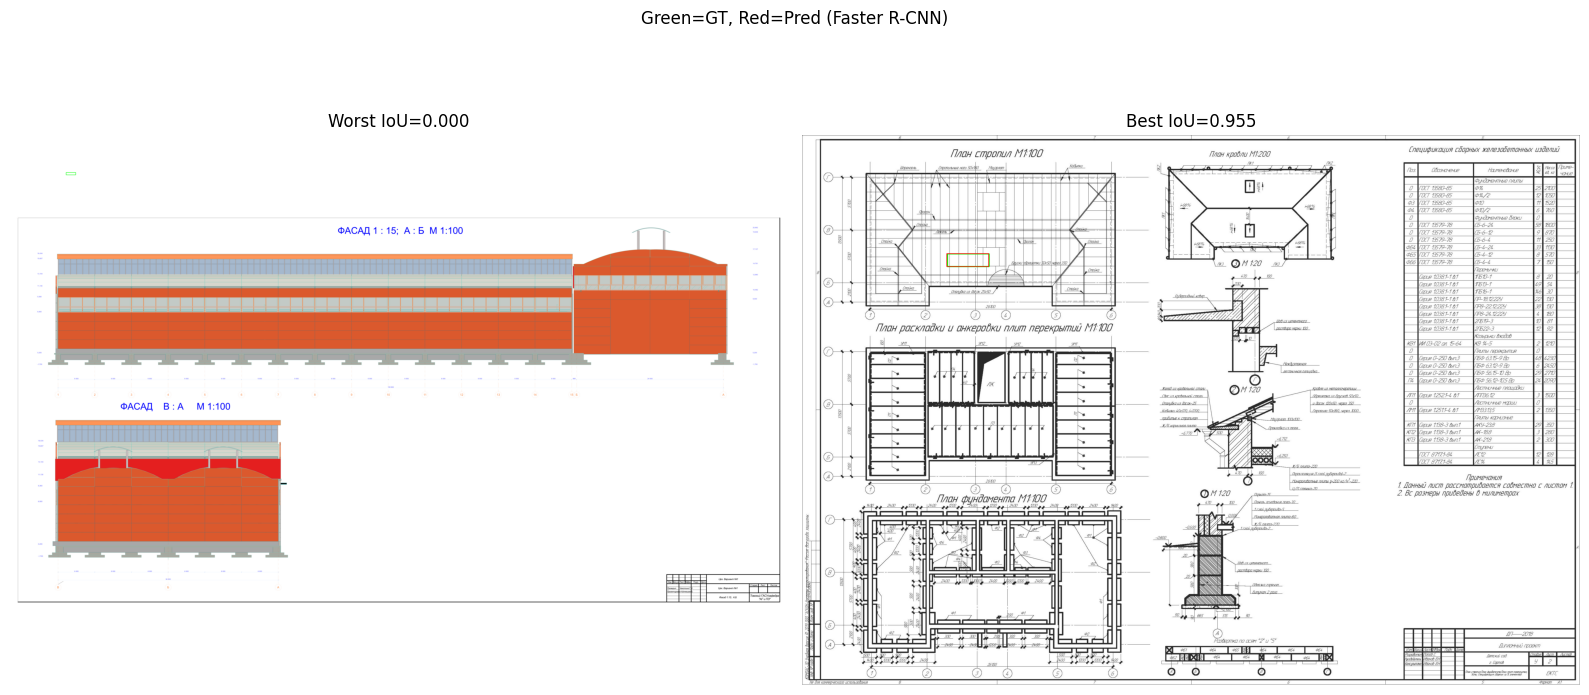

In [8]:
sorted_results = sorted(results_list, key=lambda r: r.iou)
worst = sorted_results[0]
best = sorted_results[-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, result, title_prefix in zip(axes, [worst, best], ["Worst", "Best"]):
    img_path = [p for p in all_real_images if p.name == result.image_name][0]
    img, _ = load_image_and_labels(img_path, LABEL_TEST_DIR)
    vis = img.copy()
    if result.gt_bbox:
        x, y, bw, bh = result.gt_bbox
        cv2.rectangle(vis, (x, y), (x+bw, y+bh), (0, 255, 0), 3)
    if result.pred_bbox:
        x, y, bw, bh = result.pred_bbox
        cv2.rectangle(vis, (x, y), (x+bw, y+bh), (0, 0, 255), 2)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{title_prefix} IoU={result.iou:.3f}")
    ax.axis("off")

plt.suptitle("Green=GT, Red=Pred (Faster R-CNN)")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "figures" / "rcnn_best_worst.png", dpi=150)
plt.show()

## 9. Conclusions

Итог: Faster R-CNN на 35 non-donor (4 donors + 10 val_honest excluded). Differential LR, Adam, early stopping.

In [9]:
summary = {
    "model": "Faster R-CNN (ResNet50 FPN)",
    "optimizer": "Adam",
    "lr_backbone": LR_BACKBONE,
    "lr_head": LR_HEAD,
    "data": "500 synthetic train_v3 + 49 real test (eval on 35 non-donor, non-val)",
    "best_epoch": best_epoch_display,
    "epochs": len(train_loss_history),
    "train_time_min": round(elapsed/60, 1),
    "best_conf": best_conf,
    "iou_mean": round(metrics['iou_mean'], 3),
    "iou_std": round(metrics['iou_std'], 3),
    "precision": round(metrics['precision'], 3),
    "recall": round(metrics['recall'], 3),
    "f1": round(metrics['f1'], 3),
    "detection_rate": round(metrics['detection_rate'], 3),
}

import json
with open(ARTIFACTS_DIR / "metrics" / "rcnn_results.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Summary saved to artifacts/metrics/rcnn_results.json")
print(json.dumps(summary, indent=2))

Summary saved to artifacts/metrics/rcnn_results.json
{
  "model": "Faster R-CNN (ResNet50 FPN)",
  "optimizer": "Adam",
  "lr_backbone": 0.0001,
  "lr_head": 0.001,
  "data": "500 synthetic train_v3 + 49 real test (eval on 35 non-donor, non-val)",
  "best_epoch": 27,
  "epochs": 30,
  "train_time_min": 105.0,
  "best_conf": 0.05,
  "iou_mean": 0.731,
  "iou_std": 0.341,
  "precision": 0.949,
  "recall": 0.822,
  "f1": 0.881,
  "detection_rate": 0.867
}


## 10. Save Results to Git

⚠️ **Запустить после обучения!** Сохраняет метрики и графики в репозиторий.


In [10]:
if IN_COLAB:
    try:
        from google.colab import userdata
        token = userdata.get('GITHUB_TOKEN')
    except Exception:
        token = None

    if token:
        %cd /content/aie-group-2-sapar
        !git config user.email "183649607+Sapar-hub@users.noreply.github.com"
        !git config user.name "Saparmyrat"
        !git remote set-url origin https://{token}@github.com/Sapar-hub/aie-group-2-sapar.git
        !git add -A
        !git commit -m "exp05: Faster R-CNN results and metrics"
        !git push origin main
    else:
        print("GITHUB_TOKEN not set. Skipping git push.")

/content/aie-group-2-sapar
[master f416706] exp05: Faster R-CNN results and metrics
 4 files changed, 17 insertions(+)
 create mode 100644 project/artifacts/figures/rcnn_best_worst.png
 create mode 100644 project/artifacts/figures/rcnn_loss.png
 create mode 100644 project/artifacts/metrics/rcnn_results.json
 create mode 100644 project/artifacts/models/rcnn_best.pth
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/Sapar-hub/aie-group-2-sapar.git'
